In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
df = pd.read_csv("dataset/train.csv")
pd.set_option('display.max_columns',25)

In [3]:
df.head()

,customer_id,Name,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,fffe4300490044003600300030003800,Pattie Morrisey,18,F,XW0DQ7H,Village,Platinum Membership,2017-08-17,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,16:08:02,17,300.63,53005.25,17.0,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,2
1,fffe43004900440032003100300035003700,Traci Peery,32,F,5K0N3X1,City,Premium Membership,2017-08-28,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,16,306.34,12838.38,10.0,NaN,Yes,No,Yes,Solved,Quality Customer Care,1
2,fffe4300490044003100390032003600,Merideth Mcmeen,44,F,1F2TCL3,Town,No Membership,2016-11-11,Yes,CID12313,Gift Vouchers/Coupons,Desktop,Wi-Fi,22:53:21,14,516.16,21027.00,22.0,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,5
3,fffe43004900440036003000330031003600,Eufemia Cardwell,37,M,VJGJ33N,City,No Membership,2016-10-29,Yes,CID3793,Gift Vouchers/Coupons,Desktop,Mobile_Data,15:57:50,11,53.27,25239.56,6.0,567.66,No,Yes,Yes,Unsolved,Poor Website,5
4,fffe43004900440031003900350030003600,Meghan Kosak,31,F,SVZXCWB,City,No Membership,2017-09-12,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Mobile_Data,15:46:44,20,113.13,24483.66,16.0,663.06,No,Yes,Yes,Solved,Poor Website,5


# Understanding the data

In [5]:
df.shape

(36992, 25)

In [6]:
df.columns.values # df.columns

array(['customer_id', 'Name', 'age', 'gender', 'security_no',
       'region_category', 'membership_category', 'joining_date',
       'joined_through_referral', 'referral_id', 'preferred_offer_types',
       'medium_of_operation', 'internet_option', 'last_visit_time',
       'days_since_last_login', 'avg_time_spent', 'avg_transaction_value',
       'avg_frequency_login_days', 'points_in_wallet',
       'used_special_discount', 'offer_application_preference',
       'past_complaint', 'complaint_status', 'feedback',
       'churn_risk_score'], dtype=object)

In [7]:
df.describe()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
count,36992.000000,36992.000000,36992.000000,36992.000000,33549.000000,36992.000000
mean,37.118161,-41.915576,243.472334,29271.194003,686.882199,3.463397
std,15.867412,228.819900,398.289149,19444.806226,194.063624,1.409661
min,10.000000,-999.000000,-2814.109110,800.460000,-760.661236,-1.000000
25%,23.000000,8.000000,60.102500,14177.540000,616.150000,3.000000
50%,37.000000,12.000000,161.765000,27554.485000,697.620000,4.000000
75%,51.000000,16.000000,356.515000,40855.110000,763.950000,5.000000
max,64.000000,26.000000,3235.578521,99914.050000,2069.069761,5.000000


In [8]:
df.info()       # it includes dtypes and count even for categorical data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   36992 non-null  object 
 1   Name                          36992 non-null  object 
 2   age                           36992 non-null  int64  
 3   gender                        36992 non-null  object 
 4   security_no                   36992 non-null  object 
 5   region_category               31564 non-null  object 
 6   membership_category           36992 non-null  object 
 7   joining_date                  36992 non-null  object 
 8   joined_through_referral       36992 non-null  object 
 9   referral_id                   36992 non-null  object 
 10  preferred_offer_types         36704 non-null  object 
 11  medium_of_operation           36992 non-null  object 
 12  internet_option               36992 non-null  object 
 13  l

In [9]:
df.isnull().sum()      # to remve the null values

customer_id                        0
Name                               0
age                                0
gender                             0
security_no                        0
region_category                 5428
membership_category                0
joining_date                       0
joined_through_referral            0
referral_id                        0
preferred_offer_types            288
medium_of_operation                0
internet_option                    0
last_visit_time                    0
days_since_last_login              0
avg_time_spent                     0
avg_transaction_value              0
avg_frequency_login_days           0
points_in_wallet                3443
used_special_discount              0
offer_application_preference       0
past_complaint                     0
complaint_status                   0
feedback                           0
churn_risk_score                   0
dtype: int64

In [10]:
# Therefore region_category, preferred_offer_types and points_in_wallet are to be handled
# pointsinwallet is only float

In [11]:
# little more checking

In [12]:
df.iloc[1]   

customer_id                     fffe43004900440032003100300035003700
Name                                                     Traci Peery
age                                                               32
gender                                                             F
security_no                                                  5K0N3X1
region_category                                                 City
membership_category                               Premium Membership
joining_date                                              2017-08-28
joined_through_referral                                            ?
referral_id                                                 CID21329
preferred_offer_types                          Gift Vouchers/Coupons
medium_of_operation                                          Desktop
internet_option                                          Mobile_Data
last_visit_time                                             12:38:13
days_since_last_login             

In [13]:
# or
df.filter(items=['feedback','age',1], axis=0)    #or df[['feedback','age']]

,customer_id,Name,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
1,fffe43004900440032003100300035003700,Traci Peery,32,F,5K0N3X1,City,Premium Membership,2017-08-28,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,16,306.34,12838.38,10.0,NaN,Yes,No,Yes,Solved,Quality Customer Care,1


In [14]:
type(df['region_category'])

pandas.core.series.Series

In [15]:
df['feedback'].value_counts()   # or df.feedbacl=k.value_counts() to get the all kind of data in it

feedback
Poor Product Quality        6350
No reason specified         6290
Too many ads                6279
Poor Website                6271
Poor Customer Service       6252
Reasonable Price            1417
User Friendly Website       1391
Products always in Stock    1382
Quality Customer Care       1360
Name: count, dtype: int64

### handle missing values

In [17]:
print(df['region_category'].mode())
print(df.preferred_offer_types.mode())
print()
print(df.points_in_wallet.mode())
print(df.points_in_wallet.mean())


0    Town
Name: region_category, dtype: object
0    Gift Vouchers/Coupons
Name: preferred_offer_types, dtype: object

0    705.07
Name: points_in_wallet, dtype: float64
686.8821987429081


In [18]:
# # For categorical coln
# # considering frequent value to be considered for NaN

df['region_category']= df['region_category'].fillna(df.region_category.mode()[0])
df['preferred_offer_types']= df['preferred_offer_types'].fillna(df.preferred_offer_types.mode()[0])
# For numerical coln
# choose mean
df['points_in_wallet']= df['points_in_wallet'].fillna(df.points_in_wallet.mean())

In [19]:
# or
# df.apply(lambda x: df.x.fillna(df[x].mode()[0]) if df[x].dtype == "object" else df.x.mean())
# 

In [20]:
df.isnull().sum()

customer_id                     0
Name                            0
age                             0
gender                          0
security_no                     0
region_category                 0
membership_category             0
joining_date                    0
joined_through_referral         0
referral_id                     0
preferred_offer_types           0
medium_of_operation             0
internet_option                 0
last_visit_time                 0
days_since_last_login           0
avg_time_spent                  0
avg_transaction_value           0
avg_frequency_login_days        0
points_in_wallet                0
used_special_discount           0
offer_application_preference    0
past_complaint                  0
complaint_status                0
feedback                        0
churn_risk_score                0
dtype: int64

In [21]:
df.count()    # or see in df.describe

customer_id                     36992
Name                            36992
age                             36992
gender                          36992
security_no                     36992
region_category                 36992
membership_category             36992
joining_date                    36992
joined_through_referral         36992
referral_id                     36992
preferred_offer_types           36992
medium_of_operation             36992
internet_option                 36992
last_visit_time                 36992
days_since_last_login           36992
avg_time_spent                  36992
avg_transaction_value           36992
avg_frequency_login_days        36992
points_in_wallet                36992
used_special_discount           36992
offer_application_preference    36992
past_complaint                  36992
complaint_status                36992
feedback                        36992
churn_risk_score                36992
dtype: int64

# EDA through pandas_profiling

In [23]:
# it provides reports for datasheet which can be customized too as per specific requirements
# The report consists of the following:

# DataFrame overview,
# Each attribute on which DataFrame is defined,
# Correlations between attributes (Pearson Correlation and Spearman Correlation), and
# A sample of DataFrame.

In [24]:
# !pip install pandas_profiling

In [25]:
# pip install -U ydata-profiling

In [26]:
# pandas_profiling now is ydata_profilinh

# from ydata_profiling import ProfileReport
# profile = ProfileReport(df)
# profile.to_file(output_file="report.html")
# profile.to_notebook_iframe()

In [27]:
# highly correlated
df[['complaint_status', 'past_complaint']].head()

,complaint_status,past_complaint
0,Not Applicable,No
1,Solved,Yes
2,Solved in Follow-up,Yes
3,Unsolved,Yes
4,Solved,Yes


In [28]:
df.drop('complaint_status', axis=1, inplace=True)

In [29]:
df.columns

Index(['customer_id', 'Name', 'age', 'gender', 'security_no',
       'region_category', 'membership_category', 'joining_date',
       'joined_through_referral', 'referral_id', 'preferred_offer_types',
       'medium_of_operation', 'internet_option', 'last_visit_time',
       'days_since_last_login', 'avg_time_spent', 'avg_transaction_value',
       'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'feedback',
       'churn_risk_score'],
      dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   36992 non-null  object 
 1   Name                          36992 non-null  object 
 2   age                           36992 non-null  int64  
 3   gender                        36992 non-null  object 
 4   security_no                   36992 non-null  object 
 5   region_category               36992 non-null  object 
 6   membership_category           36992 non-null  object 
 7   joining_date                  36992 non-null  object 
 8   joined_through_referral       36992 non-null  object 
 9   referral_id                   36992 non-null  object 
 10  preferred_offer_types         36992 non-null  object 
 11  medium_of_operation           36992 non-null  object 
 12  internet_option               36992 non-null  object 
 13  l

In [31]:
# numerical columns

df1 = df[['age', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'points_in_wallet', 'churn_risk_score']]
df1.head()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
0,18,17,300.63,53005.25,781.750000,2
1,32,16,306.34,12838.38,686.882199,1
2,44,14,516.16,21027.00,500.690000,5
3,37,11,53.27,25239.56,567.660000,5
4,31,20,113.13,24483.66,663.060000,5


# Exploratory data analysis

In [33]:
df[['joining_date']].head()

,joining_date
0,2017-08-17
1,2017-08-28
2,2016-11-11
3,2016-10-29
4,2017-09-12


In [34]:
pd.to_datetime(df.joining_date).dt.day

0        17
1        28
2        11
3        29
4        12
         ..
36987    21
36988    27
36989    11
36990    15
36991    23
Name: joining_date, Length: 36992, dtype: int32

In [35]:
# Convert the string to datetime
df['joining_day'] = pd.to_datetime(df.joining_date).dt.day
df['joining_month'] = pd.to_datetime(df.joining_date).dt.month
df['joining_year'] = pd.to_datetime(df.joining_date).dt.year

In [36]:
df.head()  # new columns generated 

,customer_id,Name,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,feedback,churn_risk_score,joining_day,joining_month,joining_year
0,fffe4300490044003600300030003800,Pattie Morrisey,18,F,XW0DQ7H,Village,Platinum Membership,2017-08-17,No,xxxxxxxx,Gift Vouchers/Coupons,?,...,300.63,53005.25,17.0,781.750000,Yes,Yes,No,Products always in Stock,2,17,8,2017
1,fffe43004900440032003100300035003700,Traci Peery,32,F,5K0N3X1,City,Premium Membership,2017-08-28,?,CID21329,Gift Vouchers/Coupons,Desktop,...,306.34,12838.38,10.0,686.882199,Yes,No,Yes,Quality Customer Care,1,28,8,2017
2,fffe4300490044003100390032003600,Merideth Mcmeen,44,F,1F2TCL3,Town,No Membership,2016-11-11,Yes,CID12313,Gift Vouchers/Coupons,Desktop,...,516.16,21027.00,22.0,500.690000,No,Yes,Yes,Poor Website,5,11,11,2016
3,fffe43004900440036003000330031003600,Eufemia Cardwell,37,M,VJGJ33N,City,No Membership,2016-10-29,Yes,CID3793,Gift Vouchers/Coupons,Desktop,...,53.27,25239.56,6.0,567.660000,No,Yes,Yes,Poor Website,5,29,10,2016
4,fffe43004900440031003900350030003600,Meghan Kosak,31,F,SVZXCWB,City,No Membership,2017-09-12,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,...,113.13,24483.66,16.0,663.060000,No,Yes,Yes,Poor Website,5,12,9,2017


In [37]:
# removed extra

df.drop(["joining_date"], axis=1, inplace=True)
df.columns

Index(['customer_id', 'Name', 'age', 'gender', 'security_no',
       'region_category', 'membership_category', 'joined_through_referral',
       'referral_id', 'preferred_offer_types', 'medium_of_operation',
       'internet_option', 'last_visit_time', 'days_since_last_login',
       'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days',
       'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'feedback',
       'churn_risk_score', 'joining_day', 'joining_month', 'joining_year'],
      dtype='object')

## Now splitting of last_time_spent

In [39]:
df[['last_visit_time']].head()


,last_visit_time
0,16:08:02
1,12:38:13
2,22:53:21
3,15:57:50
4,15:46:44


In [40]:
# extract hour, minutes and seconds
df[['last_visit_time_hour','last_visit_time_minutes','last_visit_time_seconds']] = df['last_visit_time'].astype(str).str.split(':', expand=True).astype(int)
# drop column
df.drop(['last_visit_time'], axis=1, inplace=True)

In [41]:
df.columns

Index(['customer_id', 'Name', 'age', 'gender', 'security_no',
       'region_category', 'membership_category', 'joined_through_referral',
       'referral_id', 'preferred_offer_types', 'medium_of_operation',
       'internet_option', 'days_since_last_login', 'avg_time_spent',
       'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet',
       'used_special_discount', 'offer_application_preference',
       'past_complaint', 'feedback', 'churn_risk_score', 'joining_day',
       'joining_month', 'joining_year', 'last_visit_time_hour',
       'last_visit_time_minutes', 'last_visit_time_seconds'],
      dtype='object')

# handle categorical columns


converting into numerical

In [44]:
df['gender'].value_counts()

gender
F          18490
M          18443
Unknown       59
Name: count, dtype: int64

In [45]:
gender = pd.get_dummies(df[['gender']], drop_first=True)
gender.head()

,gender_M,gender_Unknown
0,False,False
1,False,False
2,False,False
3,True,False
4,False,False


In [46]:
df['region_category'].value_counts()

region_category
Town       19556
City       12737
Village     4699
Name: count, dtype: int64

In [47]:
region = pd.get_dummies(df[['region_category']], drop_first=True)
region.head()

,region_category_Town,region_category_Village
0,False,True
1,False,False
2,True,False
3,False,False
4,False,False


In [48]:
df['membership_category'].value_counts()

membership_category
Basic Membership       7724
No Membership          7692
Gold Membership        6795
Silver Membership      5988
Premium Membership     4455
Platinum Membership    4338
Name: count, dtype: int64

In [49]:
membership = pd.get_dummies(df[['membership_category']], drop_first=True)
membership.head()

,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership
0,False,False,True,False,False
1,False,False,False,True,False
2,False,True,False,False,False
3,False,True,False,False,False
4,False,True,False,False,False


In [50]:
df.joined_through_referral.value_counts()

joined_through_referral
No     15839
Yes    15715
?       5438
Name: count, dtype: int64

In [51]:
referal = pd.get_dummies(df[['joined_through_referral']], drop_first=True)
referal.head()

,joined_through_referral_No,joined_through_referral_Yes
0,True,False
1,False,False
2,False,True
3,False,True
4,True,False


In [52]:
df.preferred_offer_types.value_counts()

preferred_offer_types
Gift Vouchers/Coupons       12637
Credit/Debit Card Offers    12274
Without Offers              12081
Name: count, dtype: int64

In [53]:
offer = pd.get_dummies(df[['preferred_offer_types']], drop_first=True)
offer.head()

,preferred_offer_types_Gift Vouchers/Coupons,preferred_offer_types_Without Offers
0,True,False
1,True,False
2,True,False
3,True,False
4,False,False


In [54]:
df.medium_of_operation.value_counts()

medium_of_operation
Desktop       13913
Smartphone    13876
?              5393
Both           3810
Name: count, dtype: int64

In [55]:
medium = pd.get_dummies(df[['medium_of_operation']], drop_first=True)
medium.head()

,medium_of_operation_Both,medium_of_operation_Desktop,medium_of_operation_Smartphone
0,False,False,False
1,False,True,False
2,False,True,False
3,False,True,False
4,False,False,True


In [56]:
df['internet_option'].value_counts()

internet_option
Wi-Fi          12413
Mobile_Data    12343
Fiber_Optic    12236
Name: count, dtype: int64

In [57]:
internet = pd.get_dummies(df[['internet_option']], drop_first=True)
internet.head()

,internet_option_Mobile_Data,internet_option_Wi-Fi
0,False,True
1,True,False
2,False,True
3,True,False
4,True,False


In [58]:
df.used_special_discount.value_counts()

used_special_discount
Yes    20342
No     16650
Name: count, dtype: int64

In [59]:
discount = pd.get_dummies(df[['used_special_discount']], drop_first=True)
discount.head()

,used_special_discount_Yes
0,True
1,True
2,False
3,False
4,False


In [60]:
df.offer_application_preference.value_counts()

offer_application_preference
Yes    20440
No     16552
Name: count, dtype: int64

In [61]:
application = pd.get_dummies(df[['offer_application_preference']], drop_first=True)
application.head()

,offer_application_preference_Yes
0,True
1,False
2,True
3,True
4,True


In [62]:
df.past_complaint.value_counts()
complaint = pd.get_dummies(df[['past_complaint']], drop_first=True)
complaint.head()

,past_complaint_Yes
0,False
1,True
2,True
3,True
4,True


In [63]:
feedback = pd.get_dummies(df[['feedback']], drop_first=True)
feedback.head()

,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website
0,False,False,False,True,False,False,False,False
1,False,False,False,False,True,False,False,False
2,False,False,True,False,False,False,False,False
3,False,False,True,False,False,False,False,False
4,False,False,True,False,False,False,False,False


### Data Train creation

In [65]:
# Concatenate dataframe -->

data_train = pd.concat([df, gender, region, membership, referal, offer, medium, internet, discount, application, complaint, feedback ], axis = 1)
data_train.head()

,customer_id,Name,age,gender,security_no,region_category,membership_category,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,...,internet_option_Wi-Fi,used_special_discount_Yes,offer_application_preference_Yes,past_complaint_Yes,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website
0,fffe4300490044003600300030003800,Pattie Morrisey,18,F,XW0DQ7H,Village,Platinum Membership,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,...,True,True,True,False,False,False,False,True,False,False,False,False
1,fffe43004900440032003100300035003700,Traci Peery,32,F,5K0N3X1,City,Premium Membership,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,...,False,True,False,True,False,False,False,False,True,False,False,False
2,fffe4300490044003100390032003600,Merideth Mcmeen,44,F,1F2TCL3,Town,No Membership,Yes,CID12313,Gift Vouchers/Coupons,Desktop,Wi-Fi,...,True,False,True,True,False,False,True,False,False,False,False,False
3,fffe43004900440036003000330031003600,Eufemia Cardwell,37,M,VJGJ33N,City,No Membership,Yes,CID3793,Gift Vouchers/Coupons,Desktop,Mobile_Data,...,False,False,True,True,False,False,True,False,False,False,False,False
4,fffe43004900440031003900350030003600,Meghan Kosak,31,F,SVZXCWB,City,No Membership,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Mobile_Data,...,False,False,True,True,False,False,True,False,False,False,False,False


In [66]:
# drop unnecessary columns
data_train.drop(["customer_id", "Name", "gender", "security_no", "region_category", "membership_category", "joined_through_referral", "referral_id", "preferred_offer_types", "medium_of_operation", "internet_option", "used_special_discount", "offer_application_preference", "past_complaint", "feedback", "avg_frequency_login_days" ], axis = 1, inplace = True)

In [67]:
data_train.shape

(36992, 41)

In [68]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 41 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   age                                          36992 non-null  int64  
 1   days_since_last_login                        36992 non-null  int64  
 2   avg_time_spent                               36992 non-null  float64
 3   avg_transaction_value                        36992 non-null  float64
 4   points_in_wallet                             36992 non-null  float64
 5   churn_risk_score                             36992 non-null  int64  
 6   joining_day                                  36992 non-null  int32  
 7   joining_month                                36992 non-null  int32  
 8   joining_year                                 36992 non-null  int32  
 9   last_visit_time_hour                         36992 non-null  int32  
 10

## Test Dataset

In [70]:
tf = pd.read_csv("dataset/test.csv")
tf.head()

,customer_id,Name,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback
0,fffe43004900440031003700300030003400,Alethia Meints,50,F,OQJ1XAY,Village,Premium Membership,2015-11-02,No,xxxxxxxx,Without Offers,Smartphone,Wi-Fi,07:19:30,12,386.26,40721.44,7.0,733.830000,Yes,No,No,Not Applicable,Poor Product Quality
1,fffe43004900440031003900370037003300,Ming Lopez,41,M,OUQRPKO,Village,Gold Membership,2016-03-01,No,xxxxxxxx,Without Offers,Desktop,Fiber_Optic,22:21:16,11,37.80,9644.40,9.0,726.000000,Yes,No,No,Not Applicable,Poor Website
2,fffe43004900440034003800360037003000,Carina Flannigan,31,F,02J2RE7,Town,Silver Membership,2017-03-03,No,xxxxxxxx,Gift Vouchers/Coupons,Both,Mobile_Data,16:40:39,18,215.36,3693.25,21.0,713.780000,Yes,No,Yes,Solved in Follow-up,No reason specified
3,fffe43004900440036003200370033003400,Kyung Wanner,64,M,5YEQIF1,Town,Silver Membership,2017-08-18,Yes,CID8941,Credit/Debit Card Offers,?,Fiber_Optic,14:56:17,-999,44.57,36809.56,11.0,744.970000,Yes,No,Yes,No Information Available,Too many ads
4,fffe43004900440035003000370031003900,Enola Gatto,16,F,100RYB5,Town,No Membership,2015-05-05,Yes,CID5690,Without Offers,Smartphone,Mobile_Data,02:57:53,6,349.88,40675.86,8.0,299.048351,No,Yes,Yes,Solved in Follow-up,Poor Website


In [71]:
# preprocessing
# filling categorical missing column
tf['region_category']= tf['region_category'].fillna(tf['region_category'].mode()[0])
tf['preferred_offer_types']= tf['preferred_offer_types'].fillna(tf['preferred_offer_types'].mode()[0])

# handle numerical missing column
tf['points_in_wallet']= tf['points_in_wallet'].fillna(tf['points_in_wallet'].mean())

# drop one column
tf.drop('complaint_status', axis=1, inplace=True)

# Exploratory data analysis
tf["joining_day"] = pd.to_datetime(tf.joining_date).dt.day
tf["joining_month"] = pd.to_datetime(tf.joining_date).dt.month
tf["joining_year"] = pd.to_datetime(tf.joining_date).dt.year

tf.drop(["joining_date"], axis=1, inplace=True)

# Extract hour, minutes and second
tf[['last_visit_time_hour','last_visit_time_minutes','last_visit_time_seconds']] = tf['last_visit_time'].astype(str).str.split(':', expand=True).astype(int)

# Now we can drop Arrival_Time as it is of no use
tf.drop(["last_visit_time"], axis = 1, inplace = True)

# Handling categorical data
gender = pd.get_dummies(tf[['gender']], drop_first=True)
region = pd.get_dummies(tf[['region_category']], drop_first=True)
membership = pd.get_dummies(tf[['membership_category']], drop_first=True)
referal = pd.get_dummies(tf[['joined_through_referral']], drop_first=True)
offer = pd.get_dummies(tf[['preferred_offer_types']], drop_first=True)
medium = pd.get_dummies(tf[['medium_of_operation']], drop_first=True)
internet = pd.get_dummies(tf[['internet_option']], drop_first=True)
discount = pd.get_dummies(tf[['used_special_discount']], drop_first=True)
application = pd.get_dummies(tf[['offer_application_preference']], drop_first=True)
complaint = pd.get_dummies(tf[['past_complaint']], drop_first=True)
feedback = pd.get_dummies(tf[['feedback']], drop_first=True)

data_test = pd.concat([tf, gender, region, membership, referal, offer, medium, internet, discount, application, complaint, feedback ], axis = 1)

data_test.drop(["customer_id", "Name", "gender", "security_no", "region_category", "membership_category", "joined_through_referral", "referral_id", "preferred_offer_types", "medium_of_operation", "internet_option", "used_special_discount", "offer_application_preference", "past_complaint", "feedback", "avg_frequency_login_days" ], axis = 1, inplace = True)

data_test.head()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,joining_day,joining_month,joining_year,last_visit_time_hour,last_visit_time_minutes,last_visit_time_seconds,gender_M,...,internet_option_Wi-Fi,used_special_discount_Yes,offer_application_preference_Yes,past_complaint_Yes,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website
0,50,12,386.26,40721.44,733.830000,2,11,2015,7,19,30,False,...,True,True,False,False,False,True,False,False,False,False,False,False
1,41,11,37.80,9644.40,726.000000,1,3,2016,22,21,16,True,...,False,True,False,False,False,False,True,False,False,False,False,False
2,31,18,215.36,3693.25,713.780000,3,3,2017,16,40,39,False,...,False,True,False,True,False,False,False,False,False,False,False,False
3,64,-999,44.57,36809.56,744.970000,18,8,2017,14,56,17,True,...,False,True,False,True,False,False,False,False,False,False,True,False
4,16,6,349.88,40675.86,299.048351,5,5,2015,2,57,53,False,...,False,False,True,True,False,False,True,False,False,False,False,False


In [72]:
data_test.shape

(19919, 40)

# Feature Selection

Finding out the best feature which will contribute and have good relation with target variable.
* Though Algorithms like RandomForest, XGBoost, and ExtraTrees inherently perform feature selection during training.

In [74]:
data_train.columns

Index(['age', 'days_since_last_login', 'avg_time_spent',
       'avg_transaction_value', 'points_in_wallet', 'churn_risk_score',
       'joining_day', 'joining_month', 'joining_year', 'last_visit_time_hour',
       'last_visit_time_minutes', 'last_visit_time_seconds', 'gender_M',
       'gender_Unknown', 'region_category_Town', 'region_category_Village',
       'membership_category_Gold Membership',
       'membership_category_No Membership',
       'membership_category_Platinum Membership',
       'membership_category_Premium Membership',
       'membership_category_Silver Membership', 'joined_through_referral_No',
       'joined_through_referral_Yes',
       'preferred_offer_types_Gift Vouchers/Coupons',
       'preferred_offer_types_Without Offers', 'medium_of_operation_Both',
       'medium_of_operation_Desktop', 'medium_of_operation_Smartphone',
       'internet_option_Mobile_Data', 'internet_option_Wi-Fi',
       'used_special_discount_Yes', 'offer_application_preference_Yes',
  

### Assign X and Y

In [76]:
x = data_train.drop(columns=['churn_risk_score'])
x.head()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,joining_day,joining_month,joining_year,last_visit_time_hour,last_visit_time_minutes,last_visit_time_seconds,gender_M,...,internet_option_Wi-Fi,used_special_discount_Yes,offer_application_preference_Yes,past_complaint_Yes,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website
0,18,17,300.63,53005.25,781.750000,17,8,2017,16,8,2,False,...,True,True,True,False,False,False,False,True,False,False,False,False
1,32,16,306.34,12838.38,686.882199,28,8,2017,12,38,13,False,...,False,True,False,True,False,False,False,False,True,False,False,False
2,44,14,516.16,21027.00,500.690000,11,11,2016,22,53,21,False,...,True,False,True,True,False,False,True,False,False,False,False,False
3,37,11,53.27,25239.56,567.660000,29,10,2016,15,57,50,True,...,False,False,True,True,False,False,True,False,False,False,False,False
4,31,20,113.13,24483.66,663.060000,12,9,2017,15,46,44,False,...,False,False,True,True,False,False,True,False,False,False,False,False


In [77]:
y= data_train['churn_risk_score']
y.head()
y_a =y.to_numpy()   # convert to array 

In [78]:
# important feature using extratreeregressor


In [79]:
from sklearn.ensemble import ExtraTreesRegressor
selection = ExtraTreesRegressor()
selection.fit(x,y_a)

ExtraTreesRegressor()

In [80]:
print(selection.feature_importances_)

[0.02390815 0.0209317  0.02509186 0.07582209 0.06981681 0.02378373
 0.02293758 0.01419759 0.02374197 0.02389143 0.02510408 0.00983071
 0.00031501 0.01082202 0.00715698 0.03127543 0.13521322 0.03847455
 0.0314341  0.05537397 0.00844029 0.00898372 0.00985874 0.01005195
 0.00626234 0.00845905 0.00827183 0.0090465  0.01001599 0.00823483
 0.00697683 0.01151922 0.00826758 0.00794006 0.00670354 0.04883043
 0.05161464 0.04749173 0.00751081 0.04639697]


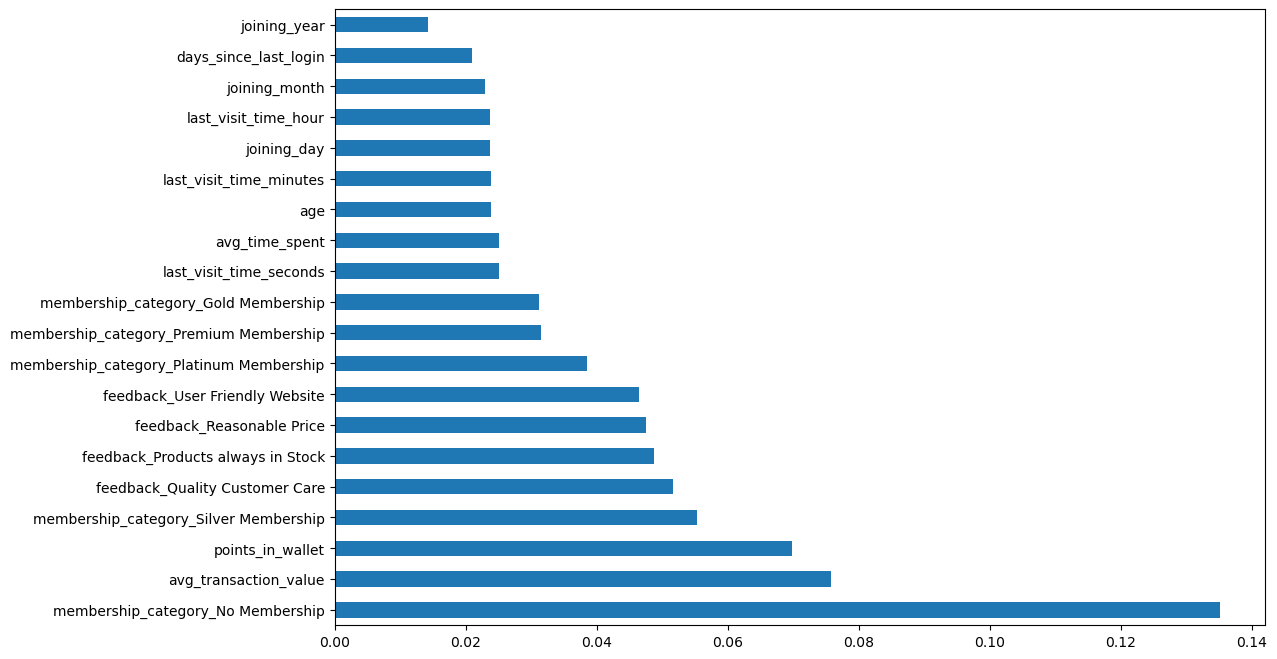

In [81]:
#plot graph of feature importances for better visualization

plt.figure(figsize = (12,8))
feat_importances = pd.Series(selection.feature_importances_, index=x.columns)
feat_importances.nlargest(20).plot(kind='barh')      
plt.show()

In [82]:
# Define the importance threshold
importance_threshold = 0.02

# Select features above the threshold
important_features = feat_importances[feat_importances > importance_threshold].index

x_reduced = x[important_features]
# removed unnecessary columns


## model training

In [84]:
data_train.head()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score,joining_day,joining_month,joining_year,last_visit_time_hour,last_visit_time_minutes,last_visit_time_seconds,...,internet_option_Wi-Fi,used_special_discount_Yes,offer_application_preference_Yes,past_complaint_Yes,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website
0,18,17,300.63,53005.25,781.750000,2,17,8,2017,16,8,2,...,True,True,True,False,False,False,False,True,False,False,False,False
1,32,16,306.34,12838.38,686.882199,1,28,8,2017,12,38,13,...,False,True,False,True,False,False,False,False,True,False,False,False
2,44,14,516.16,21027.00,500.690000,5,11,11,2016,22,53,21,...,True,False,True,True,False,False,True,False,False,False,False,False
3,37,11,53.27,25239.56,567.660000,5,29,10,2016,15,57,50,...,False,False,True,True,False,False,True,False,False,False,False,False
4,31,20,113.13,24483.66,663.060000,5,12,9,2017,15,46,44,...,False,False,True,True,False,False,True,False,False,False,False,False


***More Spliiting*** 

In [86]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_reduced,y, test_size = 0.2, random_state = 42)

In [87]:
x_train.head()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,joining_day,joining_month,last_visit_time_hour,last_visit_time_minutes,last_visit_time_seconds,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_User Friendly Website
3313,49,2,572.770000,19641.41,600.540000,26,3,7,26,13,False,False,False,False,False,False,False,False,False
28260,42,16,1427.643434,48511.87,700.920000,2,10,11,43,39,False,False,False,True,False,False,False,False,False
31412,10,-999,-779.419727,46612.57,744.650000,8,4,2,41,52,False,False,False,True,False,False,False,False,False
6700,12,9,245.010000,95291.95,686.882199,23,2,15,29,17,False,False,True,False,False,False,False,True,False
31958,28,14,308.770000,45564.89,716.280000,2,1,10,59,6,True,False,False,False,False,False,False,False,False


In [88]:
x_train.shape

(29593, 19)

In [89]:
y_train.shape

(29593,)

### Deciding on which using what algo create model 

In [91]:
# randomforest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [92]:
print("training accuracy is : ", rf.score(x_train, y_train)*100)

training accuracy is :  100.0


In [93]:
print("testing accuracy is : ", rf.score(x_test, y_test)*100)

testing accuracy is :  75.44262738207867


In [94]:
# decision tree
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [95]:
print(model.feature_importances_)

[0.03518406 0.02952476 0.04526458 0.11369221 0.36739115 0.02894765
 0.02503701 0.02868331 0.03733104 0.03798361 0.03729328 0.02416088
 0.02936474 0.02699501 0.03901282 0.02466898 0.02171316 0.02496109
 0.02279064]


In [96]:
print("testing accuracy is : ", model.score(x_test, y_test)*100)

testing accuracy is :  71.37451006892823


In [97]:
# XGBClassifier

from sklearn.preprocessing import LabelEncoder

# Assuming y_train contains the churn_risk_score values, (getdummy in 54)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)


from xgboost import XGBClassifier
xg = XGBClassifier(objective='binary:logistic')
xg.fit(x_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [98]:
# checking accuracy of test dataset
print("testing accuracy is : ", xg.score(x_test, y_test)*100)

testing accuracy is :  75.33450466279227


## Hyperparameter Tuning


* hyperparameter tuning
    1. **RandomizedSearchCV** --> Fast
    2. GridSearchCV,RandomizedSearchCV, GridSearchCV, Bayesian Optimization, Genetic Algorithms, TPE, Hyperband, and Optuna.
* Assign hyperparameters in form of dictionery
* Fit the model
* Check best paramters and best score

In [100]:
from sklearn.model_selection import RandomizedSearchCV

In [101]:
param_grid={
    'learning_rate':[1,0.5,0.1,0.01],
    'max_depth':[3,5,10,20],
    'n_estimators':[10,50,100,200]
}

In [102]:
grid = RandomizedSearchCV(XGBClassifier(objective='binary:logistic'), param_grid, verbose=3)

In [103]:
grid.fit(x_train, y_train_encoded)
grid.best_params_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END learning_rate=0.01, max_depth=10, n_estimators=10;, score=0.754 total time=   0.2s
[CV 2/5] END learning_rate=0.01, max_depth=10, n_estimators=10;, score=0.755 total time=   0.2s
[CV 3/5] END learning_rate=0.01, max_depth=10, n_estimators=10;, score=0.762 total time=   0.2s
[CV 4/5] END learning_rate=0.01, max_depth=10, n_estimators=10;, score=0.754 total time=   0.1s
[CV 5/5] END learning_rate=0.01, max_depth=10, n_estimators=10;, score=0.759 total time=   0.2s
[CV 1/5] END learning_rate=0.1, max_depth=5, n_estimators=50;, score=0.761 total time=   0.4s
[CV 2/5] END learning_rate=0.1, max_depth=5, n_estimators=50;, score=0.763 total time=   0.4s
[CV 3/5] END learning_rate=0.1, max_depth=5, n_estimators=50;, score=0.763 total time=   0.4s
[CV 4/5] END learning_rate=0.1, max_depth=5, n_estimators=50;, score=0.759 total time=   0.5s
[CV 5/5] END learning_rate=0.1, max_depth=5, n_estimators=50;, score=0.767 total ti

{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}

In [104]:
# now finally check

In [105]:
xg = XGBClassifier(n_estimators= 100, max_depth= 5, learning_rate= 0.1)
xg.fit(x_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [106]:
# # checking accuracy of test dataset
print("testing accuracy is : ", xg.score(x_test, y_test)*100)

testing accuracy is :  75.45614272198947


In [132]:
xg.save_model("model.json")

In [134]:
# Xtrain data on which based predictions are made 

In [138]:
import json

feature_names = x_train.columns.tolist()  
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)


# Save model

In [140]:
import pickle
file = 'xgboost_model.pkl'
# pickle.dump(xg, open(file, 'wb'))

In [142]:
load_model = pickle.load(open(file, 'rb'))

In [144]:
y_prep = load_model.predict(x_test)
y_prep

array([1, 3, 5, ..., 3, 3, 4], dtype=int64)

In [124]:
# xg.get_booster().save_model('xgboost_model.json')